# 02 – Split Manifest generálás
**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár akkord felismerő szoftver gépi látással  
**Notebook célja:** Reprodukálható train / validation / test felosztás létrehozása
az `all/` mappából, CSV manifest fájl formájában.

**Stratégia:** manifest-alapú split – az eredeti fájlstruktúra érintetlen marad,
a `data/split_manifest.csv` határozza meg, melyik kép melyik splitbe tartozik.

---
*Tartalomjegyzék*
1. Könyvtárak és konfiguráció
2. Inventoryzáció – `all/` mappa átnézése
3. Stratified split (70 / 15 / 15)
4. Manifest CSV mentése
5. Ellenőrzés & vizualizáció
6. Összefoglaló és következő lépések

<a id='1'></a>
## 1. Könyvtárak és konfiguráció

In [20]:
import os
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Elérési utak ─────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = PROJECT_ROOT / 'data'
ALL_DIR = DATA_ROOT / 'all'
MANIFEST_PATH = DATA_ROOT / 'split_manifest.csv'

# ── Output folder setup for saving figures ────────────────────────────────
NOTEBOOK_NAME = Path(__file__).stem if '__file__' in dir() else '02_split_manifest'
OUTPUT_DIR = PROJECT_ROOT / 'output' / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'📁 Figures will be saved to: {OUTPUT_DIR}')

def save_figure(fig, name: str):
    """Save figure to output/notebook_name/ folder."""
    path = OUTPUT_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  ✅ Saved: {path.name}')
    return path

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f'\nProjekt gyökér: {PROJECT_ROOT}')
for d in [ALL_DIR, OUTPUT_DIR]:
    status = '✅ OK' if d.exists() else '❌ Nem található'
    print(f'{status}  {d}')


📁 Figures will be saved to: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/02_split_manifest

Projekt gyökér: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/02_split_manifest


<a id='2'></a>
## 2. Inventoryzáció – `all/` mappa

In [21]:
def build_inventory(root: Path) -> pd.DataFrame:
    records = []
    if not root.exists():
        return pd.DataFrame(columns=["class", "path", "filename", "size_kb"])
    for cls_dir in sorted(root.iterdir()):
        if not cls_dir.is_dir():
            continue
        for p in cls_dir.iterdir():
            if p.suffix.lower() in IMAGE_EXTS:
                records.append({
                    "class":    cls_dir.name,
                    "path":     str(p),
                    "filename": p.name,
                    "size_kb":  round(p.stat().st_size / 1024, 2),
                })
    return pd.DataFrame(records)

df_all = build_inventory(ALL_DIR)

print(f"Összesen: {len(df_all)} kép  |  Osztályok: {df_all['class'].nunique()}")
print()
print(df_all["class"].value_counts().to_string())


Összesen: 297 kép  |  Osztályok: 8

class
B          56
F          49
C          47
D          44
A          33
E          31
G          22
No hand    15


<a id='3'></a>
## 3. Stratified split  (70 / 15 / 15)

`StratifiedShuffleSplit` garantálja, hogy minden osztályból azonos arányban
kerüljenek képek a három splitbe.  
A kétlépéses logika: először leválasztjuk a **val+test** (30 %) halmazt, majd
azt felezzük **val** és **test** részre.

In [22]:
rng = np.random.default_rng(RANDOM_SEED)

X = df_all[["path", "filename", "size_kb"]].copy()
y = df_all["class"].copy()

# 1. lépés: train (70%) vs. temp (30%)
sss1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_RATIO + TEST_RATIO,
    random_state=RANDOM_SEED
)
train_idx, temp_idx = next(sss1.split(X, y))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp,  y_temp  = X.iloc[temp_idx],  y.iloc[temp_idx]

# 2. lépés: val (50% of temp) vs. test (50% of temp)
sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=RANDOM_SEED
)
val_idx, test_idx = next(sss2.split(X_temp, y_temp))

X_val,  y_val  = X_temp.iloc[val_idx],  y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(f"Train :  {len(X_train):>4} kép  ({len(X_train)/len(df_all):.1%})")
print(f"Val   :  {len(X_val):>4} kép  ({len(X_val)/len(df_all):.1%})")
print(f"Test  :  {len(X_test):>4} kép  ({len(X_test)/len(df_all):.1%})")
print(f"Össz  :  {len(X_train)+len(X_val)+len(X_test):>4} kép")


Train :   207 kép  (69.7%)
Val   :    45 kép  (15.2%)
Test  :    45 kép  (15.2%)
Össz  :   297 kép


<a id='4'></a>
## 4. Manifest CSV mentése

In [23]:
def to_manifest(X, y, split_name):
    df = X.copy()
    df["class"] = y.values
    df["split"] = split_name
    return df

manifest = pd.concat([
    to_manifest(X_train, y_train, "train"),
    to_manifest(X_val,   y_val,   "val"),
    to_manifest(X_test,  y_test,  "test"),
], ignore_index=True)

# Oszlopok rendezése
manifest = manifest[["split", "class", "filename", "path", "size_kb"]]
manifest = manifest.sort_values(["split", "class", "filename"]).reset_index(drop=True)

# Mentés
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
manifest.to_csv(MANIFEST_PATH, index=False)

print(f"✅ Manifest elmentve: {MANIFEST_PATH}")
print(f"   Sorok száma: {len(manifest)}")
print()
print(manifest.head(10).to_string(index=False))


✅ Manifest elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/split_manifest.csv
   Sorok száma: 297

split class                  filename                                                                                                                             path  size_kb
 test     A         1762212326052.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all/A/1762212326052.jpg  3697.54
 test     A         1762212326260.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all/A/1762212326260.jpg  3673.71
 test     A         1762212326326.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all/A/1762212326326.jpg  3856.19
 test     A         1762212326478.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/

<a id='5'></a>
## 5. Ellenőrzés & vizualizáció

In [24]:
# ── Pivot tábla: osztály × split ────────────────────────────────────────────
pivot = (
    manifest
    .groupby(["class", "split"])
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="class", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
# Rendezés: train | val | test
for col in ["train", "val", "test"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["train", "val", "test"]]
pivot["össz"] = pivot.sum(axis=1)

print("Osztály-eloszlás splitenként:")
print(pivot.to_string())
print()

# ── Arány-ellenőrzés ────────────────────────────────────────────────────────
print("Tényleges arányok:")
split_counts = manifest["split"].value_counts()
for s in ["train", "val", "test"]:
    n = split_counts.get(s, 0)
    print(f"  {s:6}: {n:>4} kép  ({n/len(manifest):.1%})")


Osztály-eloszlás splitenként:
split    train  val  test  össz
class                          
A           23    5     5    33
B           39    8     9    56
C           33    7     7    47
D           31    6     7    44
E           22    5     4    31
F           34    8     7    49
G           15    3     4    22
No hand     10    3     2    15

Tényleges arányok:
  train :  207 kép  (69.7%)
  val   :   45 kép  (15.2%)
  test  :   45 kép  (15.2%)


  ✅ Saved: split_check.png


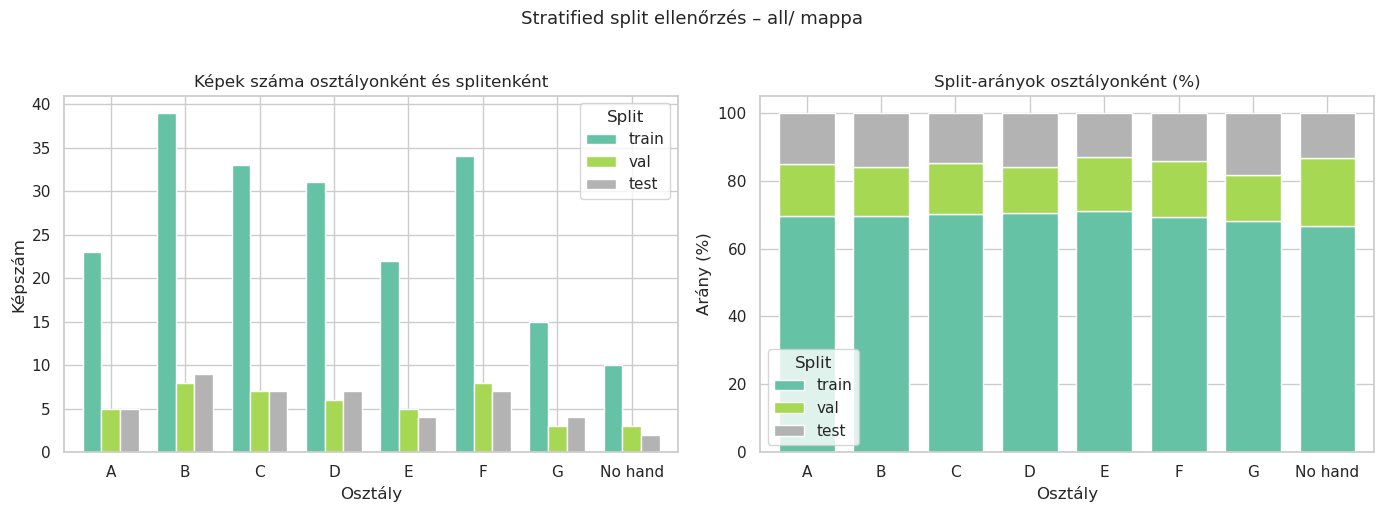

In [26]:
# ── Vizualizáció ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart – abszolút számok
pivot_plot = pivot.drop(columns=["össz"])
pivot_plot.plot(kind="bar", ax=axes[0], colormap="Set2", width=0.75)
axes[0].set_title("Képek száma osztályonként és splitenként", fontsize=12)
axes[0].set_xlabel("Osztály")
axes[0].set_ylabel("Képszám")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Split")

# Stacked bar – %-os arányok
pivot_pct = pivot_plot.div(pivot_plot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2", width=0.75)
axes[1].set_title("Split-arányok osztályonként (%)", fontsize=12)
axes[1].set_xlabel("Osztály")
axes[1].set_ylabel("Arány (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Split")

plt.suptitle("Stratified split ellenőrzés – all/ mappa", fontsize=13, y=1.02)
plt.tight_layout()
save_figure(fig, 'split_check')
plt.show()

<a id='6'></a>
## 6. Összefoglaló és következő lépések

### Mit értünk el?
- ✅ Reprodukálható 70/15/15 stratified split az `all/` mappából
- ✅ `data/split_manifest.csv` – egyetlen igazságforrás a pipeline számára
- ✅ G és No hand osztályok is jelen vannak minden splitben
- ✅ Eredeti fájlstruktúra érintetlen

### Következő lépések (`03_preprocessing.ipynb`)
Az összes következő notebook a manifestből olvas:

```python
manifest = pd.read_csv("data/split_manifest.csv")
train_df = manifest[manifest["split"] == "train"]
val_df   = manifest[manifest["split"] == "val"]
test_df  = manifest[manifest["split"] == "test"]
```

**Döntési pontok a preprocessing fázishoz:**

| # | Kérdés | Ajánlás |
|---|--------|---------|
| 1 | Célméret | 224×224 (ResNet/EfficientNet szabvány) |
| 2 | Csatornák | RGB (saját mean/std: R≈0.51, G≈0.44, B≈0.42) |
| 3 | Augmentáció | RandomHorizontalFlip, ColorJitter, RandomRotation(±15°) |
| 4 | Class weight | Igen – E és G osztályok alulreprezentáltak |
| 5 | Framework | PyTorch + torchvision transforms |